<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%203/convolutional_neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score,f1_score
import seaborn as sns
from tensorflow.keras import layers,Input
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.utils import plot_model
import math

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

import warnings

warnings.filterwarnings(
    "ignore",
    message="Do not pass an `input_shape`/`input_dim` argument",
    category=UserWarning
)

In [ ]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
class_names=['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1676s 10us/step


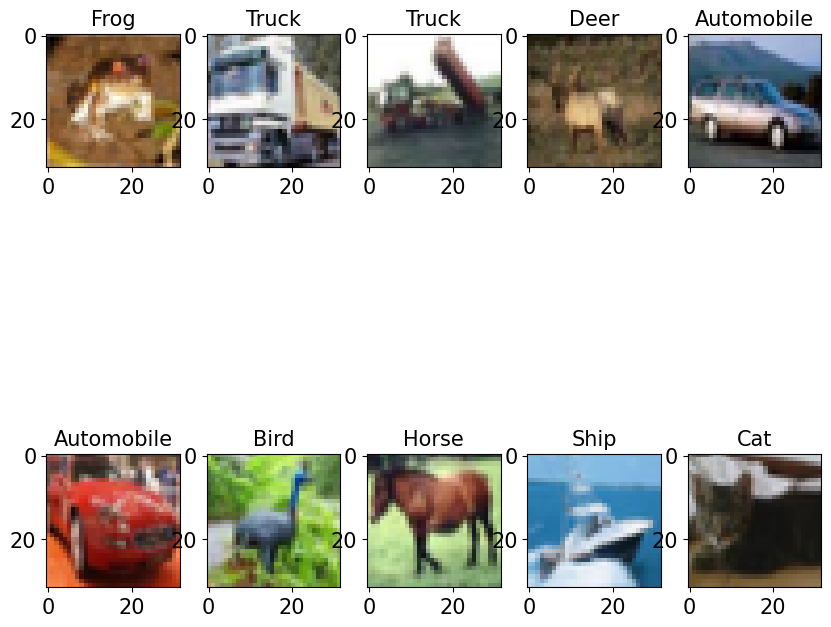

In [ ]:
plt.figure(figsize=(10,10))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])

plt.savefig("sample_images.png",dpi=600)
plt.show()


In [ ]:
print(f"Training images shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing images shape: {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


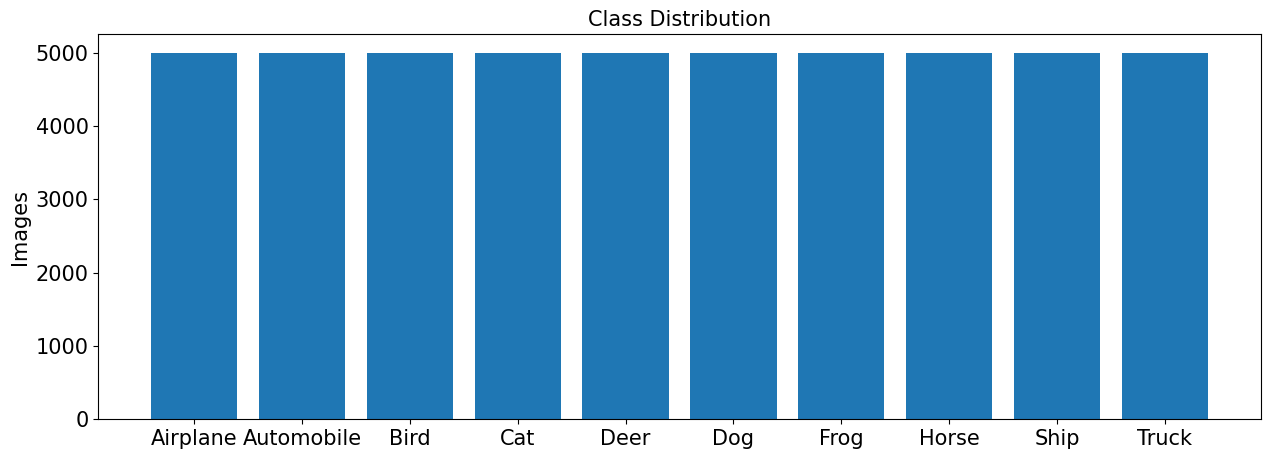

In [ ]:
unique,counts=np.unique(y_train,return_counts=True)
plt.figure(figsize=(15,5))
plt.bar(class_names, counts)
plt.ylabel("Images")
plt.title("Class Distribution")
plt.savefig("class_distribution.png",dpi=600)
plt.show()

In [ ]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

print("Training images: ",X_train.shape)
print("Testing images: ",X_test.shape)

Training images:  (50000, 32, 32, 3)
Testing images:  (10000, 32, 32, 3)


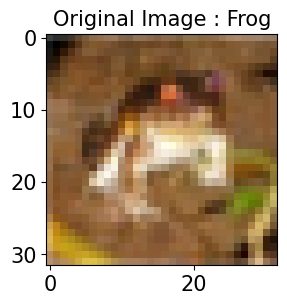

In [ ]:
plt.figure(figsize=(3,3))
image=X_train[0]
plt.imshow(image)
plt.title("Original Image : "+class_names[y_train[0][0]])
plt.savefig("original_image_1.png",dpi=600)
plt.show()

In [ ]:
def conv(kernel_size):
  model=Sequential()
  model.add(Conv2D(1,kernel_size=kernel_size,strides=1,padding='valid',input_shape=(32,32,3)))

  output=model.predict(np.expand_dims(image,axis=0))
  return output

In [ ]:
for k in [3,5,7]:
  output  =conv((k,k))
  print(f"Kernel Size: {k}x{k}")
  print("Output Shape: ",output.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Kernel Size: 3x3
Output Shape:  (1, 30, 30, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Kernel Size: 5x5
Output Shape:  (1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Kernel Size: 7x7
Output Shape:  (1, 26, 26, 1)


In [ ]:
def conv_stride_padding(stride,padding):
  model=Sequential()
  model.add(Conv2D(8,kernel_size=3,strides=stride,padding=padding,input_shape=(32,32,3)))

  output=model.predict(np.expand_dims(image,axis=0))
  return output

In [ ]:
for s in [1,2]:
  for p in ['valid','same']:
    output=conv_stride_padding(s,p)
    print(f"Stride: {s}, Padding: {p}")
    print("Output Shape: ",output.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Stride: 1, Padding: valid
Output Shape:  (1, 30, 30, 8)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Stride: 1, Padding: same
Output Shape:  (1, 32, 32, 8)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Stride: 2, Padding: valid
Output Shape:  (1, 15, 15, 8)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Stride: 2, Padding: same
Output Shape:  (1, 16, 16, 8)


In [ ]:
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.models import Model
inputs = Input(shape=(32,32,3))

conv_output = Conv2D(
    8,
    (3,3),
    activation="relu"
)(inputs)

feature_model = Model(
    inputs=inputs,
    outputs=conv_output
)

feature_maps = feature_model.predict(
    np.expand_dims(image, axis=0)
)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
(1, 30, 30, 8)


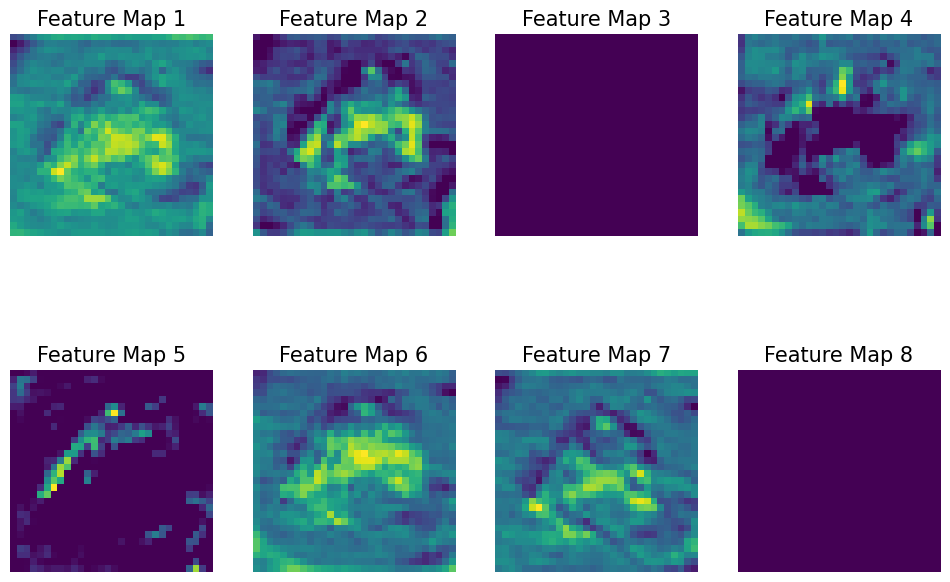

In [ ]:
plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(feature_maps[0,:,:,i])

    plt.title(f"Feature Map {i+1}")
    plt.axis("off")

plt.savefig("feature_maps.png",dpi=600)
plt.show()

In [ ]:
image=np.expand_dims(X_train[0], axis=0)
max_pool=MaxPooling2D(pool_size=(2,2),strides=2)
max_image =max_pool(image)
print("Max Pooling Output Size:",max_image.shape)

Max Pooling Output Size: (1, 16, 16, 3)


In [ ]:
avg_pool=AveragePooling2D(pool_size=(2,2),strides=2)
avg_image=avg_pool(image)
print("Average Pooling Output Size:",avg_image.shape)

Average Pooling Output Size: (1, 16, 16, 3)


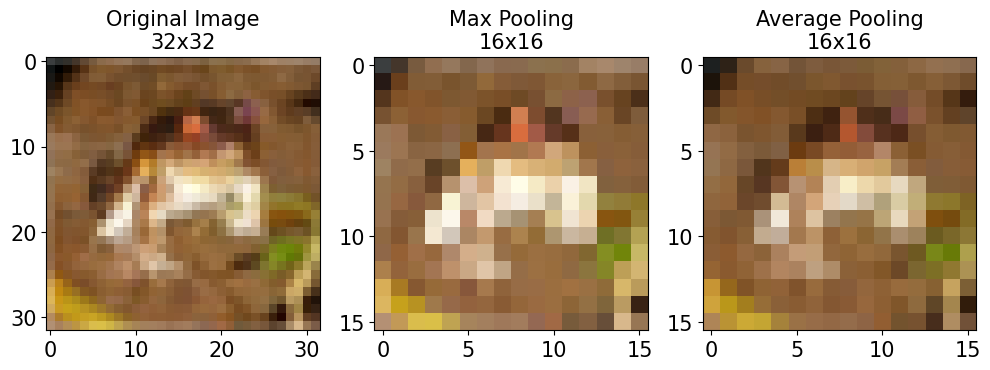

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(image[0])
plt.title("Original Image\n32x32")

plt.subplot(1,3,2)
plt.imshow(max_image[0])
plt.title("Max Pooling\n16x16")

plt.subplot(1,3,3)
plt.imshow(avg_image[0])
plt.title("Average Pooling\n16x16")

plt.show()

In [ ]:
def create_maxpool_model():

    model=Sequential()
    model.add(Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(64,(3,3),activation="relu"))
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(64,activation="relu"))
    model.add(Dense(10,activation="softmax"))


    return model

In [ ]:
def create_avgpool_model():

    model=Sequential()
    model.add(Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)))
    model.add(AveragePooling2D((2,2)))
    model.add(Conv2D(64,(3,3),activation="relu"))
    model.add(AveragePooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(64,activation="relu"))
    model.add(Dense(10,activation="softmax"))


    return model

In [ ]:
max_model=create_maxpool_model()
max_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
max_history=max_model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.4320 - loss: 1.5555 - val_accuracy: 0.5247 - val_loss: 1.3301
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.5713 - loss: 1.2043 - val_accuracy: 0.6073 - val_loss: 1.1170
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6243 - loss: 1.0658 - val_accuracy: 0.6157 - val_loss: 1.1125
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.6563 - loss: 0.9848 - val_accuracy: 0.6424 - val_loss: 1.0170
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.6805 - loss: 0.9183 - val_accuracy: 0.6577 - val_loss: 0.9939
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.6970 - loss: 0.8689 - val_accuracy: 0.6651 - val_loss: 0.9774
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.7146 - loss: 0.8235 - val_accuracy: 0.6709 - val_loss: 0.9715
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.7258 -

In [ ]:
avg_model=create_avgpool_model()
avg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
avg_history=avg_model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.4231 - loss: 1.5957 - val_accuracy: 0.5164 - val_loss: 1.3660
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.5432 - loss: 1.2835 - val_accuracy: 0.5663 - val_loss: 1.2429
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.5930 - loss: 1.1531 - val_accuracy: 0.6060 - val_loss: 1.1418
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6265 - loss: 1.0651 - val_accuracy: 0.6111 - val_loss: 1.1026
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.6531 - loss: 0.9913 - val_accuracy: 0.6399 - val_loss: 1.0342
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6726 - loss: 0.9346 - val_accuracy: 0.6440 - val_loss: 1.0242
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.6895 - loss: 0.8872 - val_accuracy: 0.6625 - val_loss: 0.9949
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.7032 -

In [ ]:
max_loss,max_acc=max_model.evaluate(X_test,y_test)
avg_loss,avg_acc=avg_model.evaluate(X_test,y_test)
print("Max Pooling Accuracy:",max_acc)
print("Average Pooling Accuracy:",avg_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6688 - loss: 0.9820
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6686 - loss: 0.9681
Max Pooling Accuracy: 0.6687999963760376
Average Pooling Accuracy: 0.6686000227928162


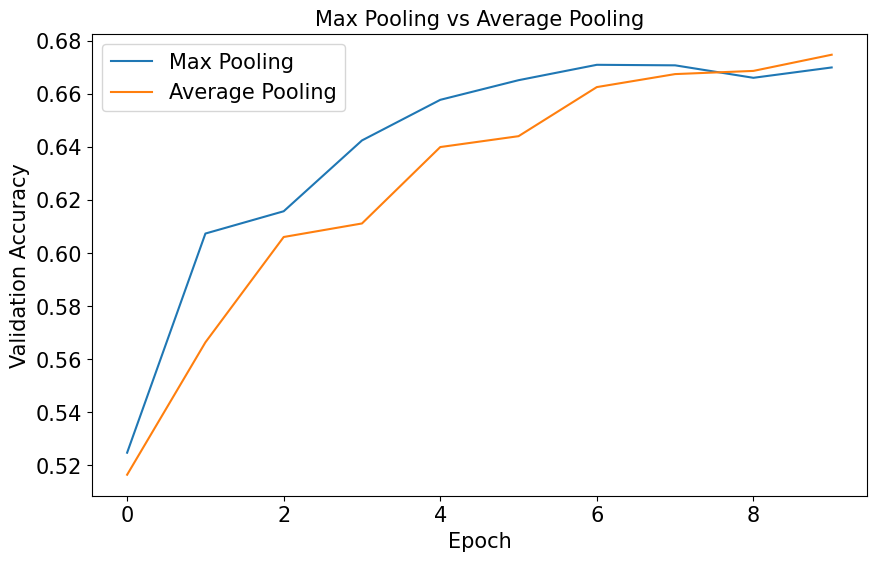

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(
    max_history.history["val_accuracy"],
    label="Max Pooling"
)
plt.plot(
    avg_history.history["val_accuracy"],
    label="Average Pooling"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Max Pooling vs Average Pooling")
plt.legend()
plt.savefig("max_vs_avg_pooling.png",dpi=600)

plt.show()

In [ ]:
model=Sequential()
model.add(Conv2D(16,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))


In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,650 (1.02 MB)

 Trainable params: 268,650 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist=model.fit(X_train,y_train_cat,epochs=20,batch_size=32,validation_split=0.2)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.4598 - loss: 1.5009 - val_accuracy: 0.5357 - val_loss: 1.3014
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.5919 - loss: 1.1571 - val_accuracy: 0.6230 - val_loss: 1.0916
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.6487 - loss: 1.0020 - val_accuracy: 0.6490 - val_loss: 1.0029
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6836 - loss: 0.9008 - val_accuracy: 0.6691 - val_loss: 0.9641
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.7110 - loss: 0.8210 - val_accuracy: 0.6579 - val_loss: 1.0190
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.7390 - loss: 0.7488 - val_accuracy: 0.6765 - val_loss: 0.9649
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.7620 - loss: 0.6776 - val_accuracy: 0.6803 - val_loss: 0.9405
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.7834 -

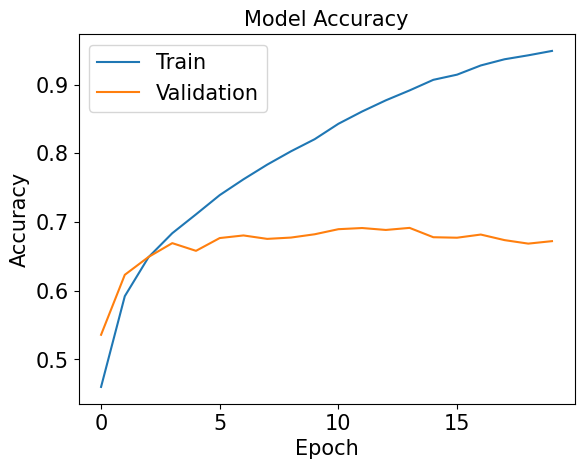

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.savefig("model_accuracy.png",dpi=600)
plt.show()

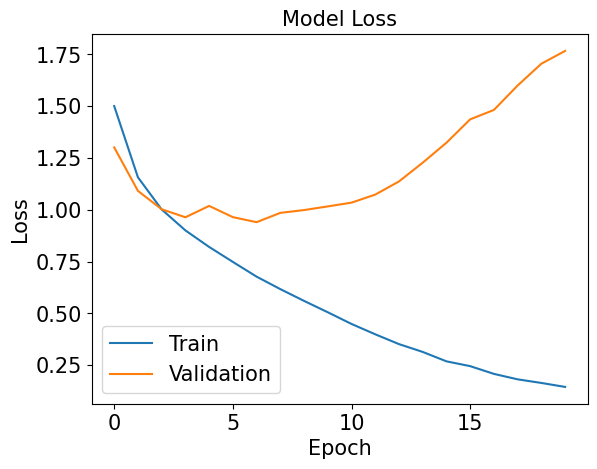

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.savefig("model_loss.png",dpi=600)
plt.show()

In [ ]:
loss,accuracy=model.evaluate(X_test,y_test_cat)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6682 - loss: 1.7927
Test Loss:  1.7926900386810303
Test Accuracy:  0.6682000160217285


In [ ]:
pred=model.predict(X_test)
pred_class=np.argmax(pred,axis=1)
actual=y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
print("Precision:",precision_score(actual,pred_class,average="weighted"))
print("Recall:",recall_score(actual,pred_class,average="weighted"))
print("F1 Score:",f1_score(actual,pred_class,average="weighted"))


Precision: 0.6731512971228037
Recall: 0.6682
F1 Score: 0.6681867756564608


In [ ]:
print(classification_report(actual,pred_class,target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.72      0.69      0.70      1000
  Automobile       0.79      0.77      0.78      1000
        Bird       0.48      0.65      0.55      1000
         Cat       0.54      0.44      0.48      1000
        Deer       0.60      0.64      0.62      1000
         Dog       0.61      0.55      0.58      1000
        Frog       0.70      0.73      0.72      1000
       Horse       0.75      0.71      0.73      1000
        Ship       0.74      0.82      0.78      1000
       Truck       0.79      0.70      0.74      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



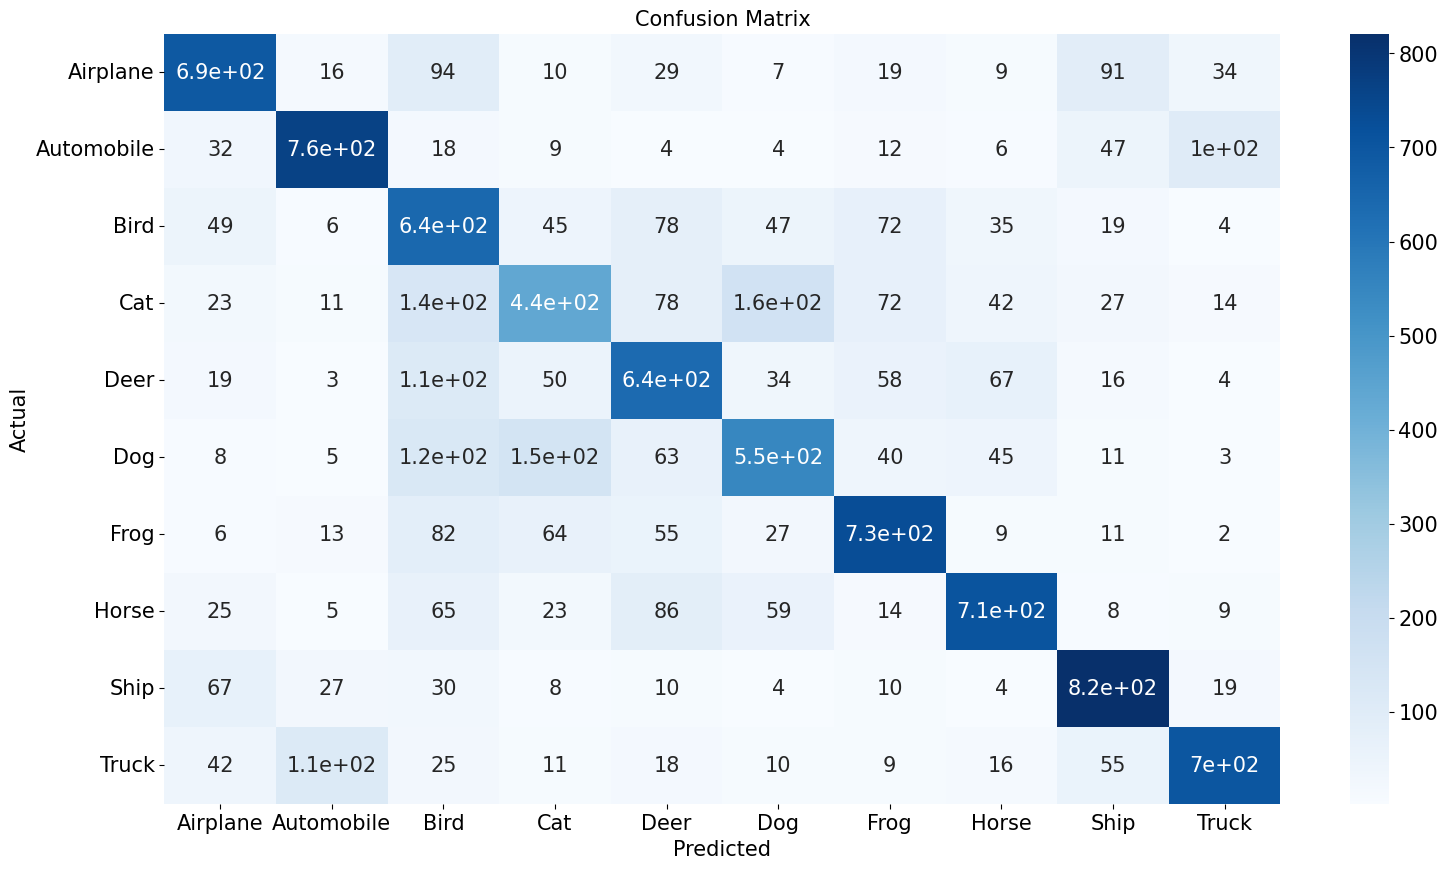

In [41]:
cm=confusion_matrix(actual,pred_class)
plt.figure(figsize=(18,10))
sns.heatmap(cm,annot=True,cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png",dpi=600)
plt.show()

In [ ]:
print("Total Trainable Parameters:")
print(model.count_params())

Total Trainable Parameters:
268650


In [ ]:
model_64 = Sequential([

    layers.Input(shape=(32,32,3)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

model_64.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import time
start = time.time()

history_64 = model_64.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

time_64 = time.time() - start

loss_64, accuracy_64 = model_64.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("64 Filter Accuracy:", accuracy_64)
print("64 Filter Training Time:", time_64, "seconds")
print("64 Filter Parameters:", model_64.count_params())

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 43ms/step - accuracy: 0.4871 - loss: 1.4280 - val_accuracy: 0.5702 - val_loss: 1.2101
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.6230 - loss: 1.0735 - val_accuracy: 0.6341 - val_loss: 1.0438
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.6741 - loss: 0.9359 - val_accuracy: 0.6670 - val_loss: 0.9516
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.7140 - loss: 0.8223 - val_accuracy: 0.6763 - val_loss: 0.9153
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 40ms/step - accuracy: 0.7421 - loss: 0.7388 - val_accuracy: 0.6919 - val_loss: 0.8910
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7710 - loss: 0.6557 - val_accuracy: 0.6980 - val_loss: 0.9028
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7955 - loss: 0.5808 - val_accuracy: 0.7135 - val_loss: 0.8853
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.8189 -